In [1]:
import cv2 
import IPython
import numpy as np
import pandas as pd

# from qdrant_client import QdrantClient 
# from qdrant_client.models import Distance, VectorParams, PointStruct

In [16]:
# CLIENT = QdrantClient(host='192.168.0.131', port=6333)   

In [2]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [3]:
def image_from_video(row):
    cap = cv2.VideoCapture(row['filepath'])
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    # frame_num = 0
    # while True:
    #     ret, frame = cap.read()
    #     if not ret or frame is None or frame_num == row['frame_num']:
    #         break 
    #     else:
    #         frame_num += 1

    ret, frame = cap.read()
    h, w = (row['img_height'], row['img_width'])
    cv2.rectangle(frame, (int(row['x1'] * w), int(row['y1'] * h)), 
                         (int(row['x2'] * w), int(row['y2'] * h)), (0, 0, 255), 3)
    show_image(frame)

In [4]:
def parse_vector(vector):
    return np.array([float(x) for x in vector.split('\n')])

In [5]:
src = '~/billions.csv'
df = pd.read_csv(src, index_col=0)
# df['filepath'] = '/home/amos/programs/CineFace/input.m4a'
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,mouth_right_y,mouth_left_x,mouth_left_y,confidence,face_num,frame_num,img_width,img_height,filepath,encoding
0,0.819,0.444,0.906,0.564,0.872,0.478,0.874,0.522,0.864,0.495,...,0.487,0.847,0.520,0.997,0,480,1920,1080,/home/amos/media/tv/Billions.S01-S06.1080p.Blu...,-0.056782\n0.0407789\n0.0695966\n-0.0311511\n-...
1,0.819,0.444,0.908,0.566,0.872,0.477,0.878,0.520,0.866,0.493,...,0.491,0.850,0.523,0.997,0,504,1920,1080,/home/amos/media/tv/Billions.S01-S06.1080p.Blu...,-0.0712987\n0.0471237\n0.0718096\n-0.0303338\n...
2,0.827,0.448,0.912,0.569,0.880,0.476,0.879,0.527,0.869,0.491,...,0.483,0.851,0.522,0.999,0,528,1920,1080,/home/amos/media/tv/Billions.S01-S06.1080p.Blu...,-0.0444076\n0.025435\n0.0841356\n-0.0502343\n-...
3,0.826,0.444,0.916,0.569,0.882,0.474,0.881,0.525,0.871,0.483,...,0.477,0.852,0.516,0.999,0,552,1920,1080,/home/amos/media/tv/Billions.S01-S06.1080p.Blu...,-0.0395809\n0.0226133\n0.0695686\n-0.0458262\n...
4,0.827,0.444,0.917,0.569,0.880,0.476,0.883,0.525,0.873,0.493,...,0.488,0.855,0.525,0.999,0,576,1920,1080,/home/amos/media/tv/Billions.S01-S06.1080p.Blu...,-0.0554932\n0.0499549\n0.0654113\n-0.0480948\n...


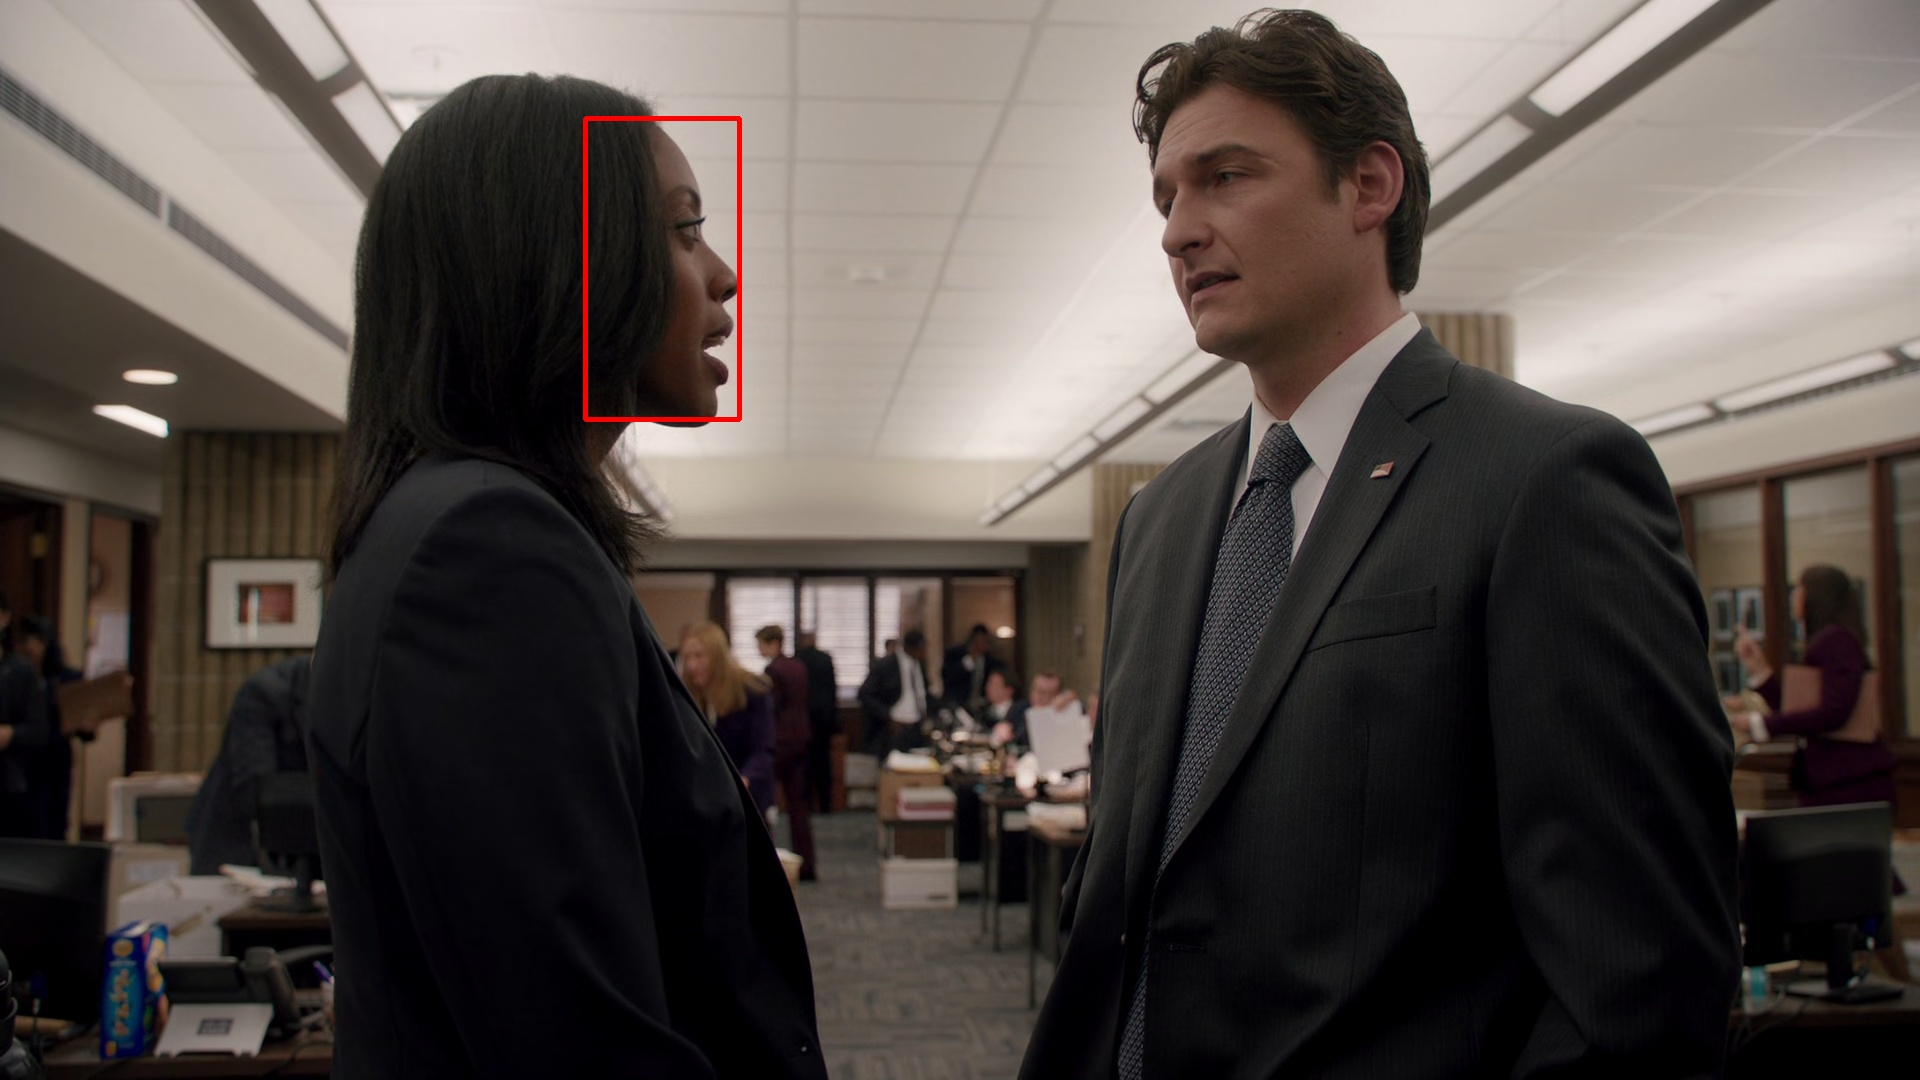

In [11]:
image_from_video(df.iloc[147])

In [7]:
collections = [x.name for x in CLIENT.get_collections().collections]
if 'FacialEmbeddings' not in collections:
    CLIENT.recreate_collection(collection_name='FacialEmbeddings',
                                vectors_config=VectorParams(size=128, distance=Distance.COSINE))

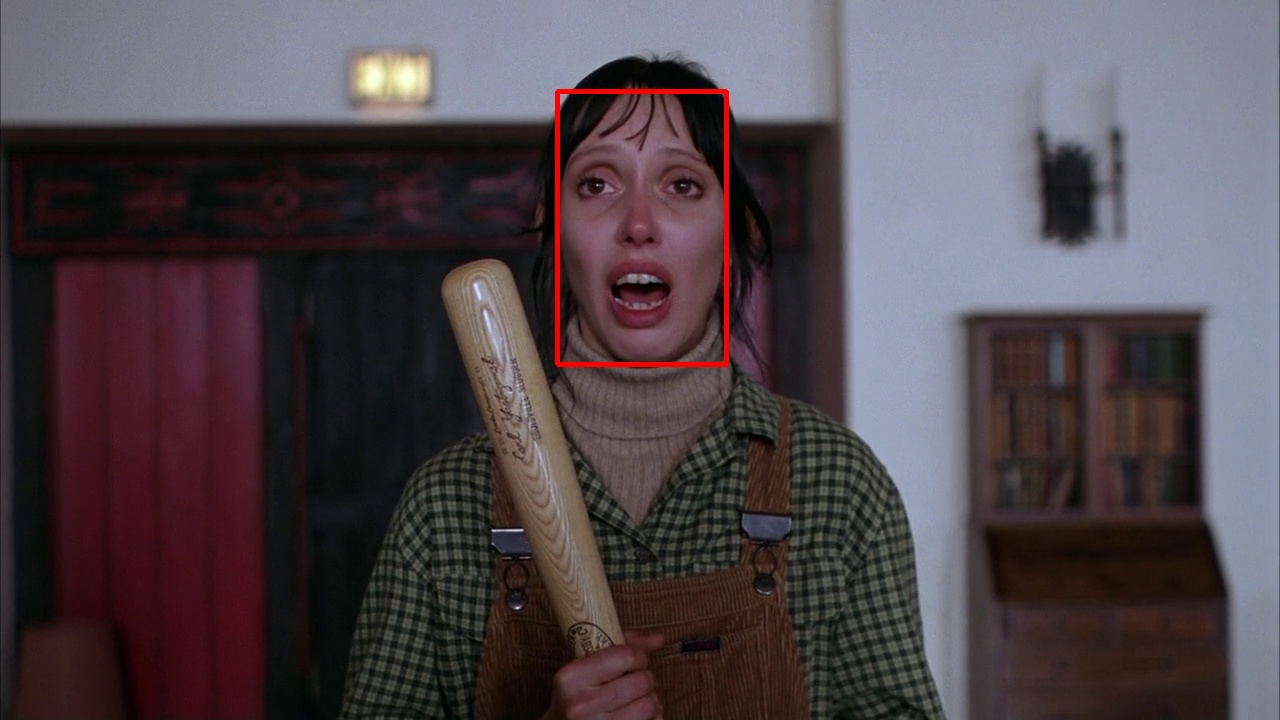